# Indian Traffic Detection: YOLO26 Fine-Tuning + PCU Congestion Analyzer

Fine-tunes YOLO26 on Indian traffic imagery and turns raw detections into a **Passenger Car Unit (PCU) congestion index** — the metric Indian traffic engineers actually use (per IRC SP-41 / IRC:106-1990) to normalize mixed vehicle types into one comparable congestion number.

**Dataset:** [Indian Traffic Objects](https://universe.roboflow.com/amit-3ttxd/indian-traffic-objects) (Roboflow Universe) — 2.8k images, 9 classes: Bus, Car, Fixed Obstacle, Modified, Three Wheeler, Tractor, Truck, Two Wheeler, Vikram.

## Why fine-tune at all?

COCO-pretrained detectors under-detect autorickshaws, tempos/Vikrams, and Indian tractor-trailers, since none of these exist as COCO classes. A model trained only on Western traffic imagery simply doesn't have the vocabulary for mixed Indian traffic.

## Approach

* **Hyperparameter selection over blind defaults.** With only ~2.8k images, the wrong learning rate or augmentation strength can either overfit or destroy the pretrained COCO features. Three configs (near-default baseline, a frozen-backbone conservative fine-tune, and a heavier-augmentation run) were trained for a short, equal epoch budget and compared before committing to a full run. The three landed within 0.02 mAP50-95 of each other — baseline and conservative essentially tied (~0.645), aggressive augmentation trailed slightly (~0.625), likely because heavy mixup/rotation needs more than 12 epochs to pay off. The choice was data-driven, even if the margin was modest.
* **Checkpointed to Google Drive**, so a dropped Colab session doesn't cost lost training time.
* **Class imbalance acknowledged, not hidden.** Fixed Obstacle is the most represented class in the dataset (~2,600 instances) — more than double any other class — while Modified (~400) and Two Wheeler (~700) are the most underrepresented. That imbalance doesn't map cleanly onto accuracy, though: Fixed Obstacle still finishes near the bottom on mAP50-95 despite having the most data, because the label covers visually inconsistent things (barricades, potholes, debris, dividers). Two Wheeler's weak AP looks more like a small-object/occlusion problem than a data-volume one. Both patterns are reported directly below rather than smoothed into a single aggregate mAP.

## Standout feature: PCU Congestion Analyzer

Raw bounding boxes are the easy part. This project converts detections into a domain-specific traffic engineering metric: PCU weighting treats a bus as ~3x the road-space "cost" of a car, a two-wheeler as ~0.5x, and so on, then plots the weighted occupancy over a video timeline to surface peak congestion moments — the same normalization real transportation studies use, not an ad-hoc vehicle count.

## Results

**mAP50: 0.890 · mAP50-95: 0.693**

| Class | mAP50 | mAP50-95 |
|---|---|---|
| Truck | 0.960 | 0.752 |
| Bus | 0.942 | 0.786 |
| Tractor | 0.928 | 0.726 |
| Three Wheeler | 0.921 | 0.736 |
| Fixed Obstacle | 0.876 | 0.648 |
| Vikram | 0.868 | 0.713 |
| Car | 0.869 | 0.672 |
| Modified | 0.828 | 0.606 |
| Two Wheeler | 0.815 | 0.593 |

## Stack

`ultralytics` (YOLO26) · `roboflow` · `supervision` · OpenCV

## Persistence & Fault Tolerance

Training checkpoints are written to Google Drive every few epochs, and the training cell auto-detects an existing checkpoint on start, resuming from it rather than restarting from scratch.

**A caveat worth being upfront about:** Drive checkpointing protects *progress*, not *runtime uptime*. Free Colab can disconnect on prolonged inactivity or a closed tab regardless of what's saved to Drive — the checkpoint just guarantees a disconnect costs a few epochs instead of the whole run. For actual background execution independent of the browser, either:

- **Kaggle Notebooks** (free) — commit-and-run executes server-side, laptop-independent.
- **Colab Pro/Pro+** — has a dedicated background execution setting.

The checkpoint/resume pattern here is what makes either option safe to use in the first place.

In [2]:
!pip install -q "ultralytics>=8.4.0" supervision roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 373.3/373.3 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 108.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 5.1 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT = "/content/drive/MyDrive/indian-traffic-yolo26"
os.makedirs(DRIVE_ROOT, exist_ok=True)
print("Checkpoints and runs will be saved to:", DRIVE_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoints and runs will be saved to: /content/drive/MyDrive/indian-traffic-yolo26


In [4]:
from google.colab import userdata
os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

## 1. Downloading the dataset

In [5]:
from roboflow import Roboflow

WORKSPACE = "amit-3ttxd"
PROJECT = "indian-traffic-objects"
VERSION = 1  # check the dataset page for the latest version number

rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
project = rf.workspace(WORKSPACE).project(PROJECT)
dataset = project.version(VERSION).download("yolov11")  # YOLO26 uses the same label/ dataset.yaml format
print(dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Indian-traffic-objects-1 in yolov11:: 100%|██████████| 13268/13268 [00:04<00:00, 2949.17it/s]


/content/Indian-traffic-objects-1


## 2. Data quality check

In [9]:
import yaml
from collections import Counter
import cv2

data_yaml_path = f"{dataset.location}/data.yaml"
with open(data_yaml_path) as f:
    data_cfg = yaml.safe_load(f)
print("Classes:", data_cfg["names"])

def count_classes(split):
    label_dir = f"{dataset.location}/{split}/labels"
    counts = Counter()
    for fname in os.listdir(label_dir):
        with open(os.path.join(label_dir, fname)) as f:
            for line in f:
                counts[data_cfg["names"][int(line.split()[0])]] += 1
    return counts

def check_corrupt(split):
    img_dir = f"{dataset.location}/{split}/images"
    return [f for f in os.listdir(img_dir) if cv2.imread(os.path.join(img_dir, f)) is None]

def check_empty_labels(split):
    label_dir = f"{dataset.location}/{split}/labels"
    return [f for f in os.listdir(label_dir) if os.path.getsize(os.path.join(label_dir, f)) == 0]

for split in ["train", "valid", "test"]:
    print(f"\n--- {split} ---")
    print("class distribution:", dict(count_classes(split).most_common()))
    bad = check_corrupt(split)
    print(f"corrupt images: {len(bad)}" + (f" e.g. {bad[:3]}" if bad else ""))
    empty = check_empty_labels(split)
    print(f"images with zero annotations: {len(empty)}")

Classes: ['Bus', 'Car', 'Fixed Obstacle', 'Modified', 'Three Wheeler', 'Tractor', 'Truck', 'Two Wheeler', 'Vikram']

--- train ---
class distribution: {'Fixed Obstacle': 2625, 'Bus': 1124, 'Truck': 1083, 'Car': 959, 'Three Wheeler': 847, 'Tractor': 799, 'Vikram': 714, 'Two Wheeler': 708, 'Modified': 396}
corrupt images: 0
images with zero annotations: 3

--- valid ---
class distribution: {'Fixed Obstacle': 223, 'Truck': 101, 'Two Wheeler': 93, 'Three Wheeler': 91, 'Car': 85, 'Bus': 83, 'Tractor': 79, 'Vikram': 78, 'Modified': 37}
corrupt images: 0
images with zero annotations: 0

--- test ---
class distribution: {'Fixed Obstacle': 162, 'Truck': 60, 'Bus': 53, 'Car': 46, 'Two Wheeler': 38, 'Vikram': 34, 'Tractor': 33, 'Three Wheeler': 25, 'Modified': 11}
corrupt images: 0
images with zero annotations: 0


## Known Limitation: Class Imbalance

Fixed Obstacle is the most represented class in the training set (2,600 instances), more than double any other class, while Modified (400) and Two Wheeler (700) are the most underrepresented. This is a real constraint of the source data, not something papered over here.

Notably, the imbalance doesn't translate into a clean "more data = better AP" story: Fixed Obstacle still underperforms on mAP50-95 despite its size advantage, and Two Wheeler underperforms despite not being the smallest class.

Both patterns show up directly in the per-class AP breakdown below rather than being hidden behind a single aggregate mAP, see the discussion in the evaluation section for the likely cause of each.

## 3. Hyperparameter comparison — 3 short, documented runs

Rather than accepting Ultralytics' defaults, we test three configs for a short 12 epochs each and compare, because the right choice genuinely depends on dataset size and content:

- **`baseline`** — near-default settings. Our control group.
- **`conservative`** — low learning rate (`lr0=0.001`) + frozen backbone (`freeze=10`) + lighter augmentation (`mosaic=0.5`). Reasoning: with only ~2.8k images, aggressively updating the whole network risks destroying the general object features YOLO26 already learned from COCO. Freezing the backbone and fine-tuning gently should adapt faster to the 9 Indian-specific classes without overfitting.
- **`aggressive_aug`** — heavier augmentation (`mosaic=1.0`, `mixup=0.15`, wider `translate`/`scale`/`degrees`) at the default learning rate. Reasoning: Indian traffic scenes are visually repetitive (similar intersections, similar lighting) and cluttered/occluded (vehicles packed together) — stronger augmentation should improve robustness to that clutter and reduce overfitting to repeated scene layouts.

We compare on val mAP50-95 and pick the winner for the full training run.

In [ ]:
from ultralytics import YOLO
import pandas as pd

COMPARE_EPOCHS = 12
COMPARE_DIR = f"{DRIVE_ROOT}/hparam_compare"

configs = {
    "baseline": dict(),
    "conservative": dict(lr0=0.001, freeze=10, mosaic=0.5, cos_lr=True, warmup_epochs=3),
    "aggressive_aug": dict(mosaic=1.0, mixup=0.15, degrees=10, translate=0.2, scale=0.9, hsv_v=0.5, close_mosaic=5),
}

compare_results = []
for name, overrides in configs.items():
    print(f"\n=== Training config: {name} ===")
    model = YOLO("yolo26n.pt")
    model.train(
        data=data_yaml_path,
        epochs=COMPARE_EPOCHS,
        imgsz=640,
        batch=16,
        project=COMPARE_DIR,
        name=name,
        exist_ok=True,
        plots=False,
        **overrides,
    )
    metrics = model.val(data=data_yaml_path)
    compare_results.append({
        "config": name,
        "mAP50": round(metrics.box.map50, 4),
        "mAP50-95": round(metrics.box.map, 4),
    })

compare_df = pd.DataFrame(compare_results).sort_values("mAP50-95", ascending=False)
print("\n", compare_df)

WINNING_CONFIG = compare_df.iloc[0]["config"]
print(f"\nWinning config: {WINNING_CONFIG}")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

=== Training config: baseline ===
Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Indian-traffic-objects-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=12, erasi

## Final Fine-Tuning Run

Trains the winning configuration from the ablation above for the full epoch budget, with checkpoints written to Drive every 5 epochs. The cell is resume-safe: if interrupted by a runtime disconnect, re-running it detects the last checkpoint in Drive and continues from there instead of restarting.

In [ ]:
FINAL_EPOCHS = 50
FINAL_RUN_NAME = "final_run"
BASE_MODEL = "yolo26s.pt"  # small — more capacity than nano for the real run; swap to yolo26n.pt if GPU time is tight

last_ckpt = f"{DRIVE_ROOT}/{FINAL_RUN_NAME}/weights/last.pt"

if os.path.exists(last_ckpt):
    print("Found existing checkpoint — resuming training from", last_ckpt)
    model = YOLO(last_ckpt)
    model.train(resume=True)
else:
    print("Starting fresh training run with config:", WINNING_CONFIG)
    model = YOLO(BASE_MODEL)
    model.train(
        data=data_yaml_path,
        epochs=FINAL_EPOCHS,
        imgsz=640,
        batch=16,
        patience=15,
        save_period=5,
        project=DRIVE_ROOT,
        name=FINAL_RUN_NAME,
        exist_ok=True,
        plots=True,
        **configs[WINNING_CONFIG],
    )

BEST_WEIGHTS = f"{DRIVE_ROOT}/{FINAL_RUN_NAME}/weights/best.pt"
print("Best weights at:", BEST_WEIGHTS)

Starting fresh training run with config: conservative
Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/Indian-traffic-objects-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, m

## 5. Evaluate

In [ ]:
final_model = YOLO(BEST_WEIGHTS)
metrics = final_model.val(data=data_yaml_path)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("\nPer-class mAP50-95:")
for cls_name, ap in zip(data_cfg["names"], metrics.box.maps):
    print(f"  {cls_name}: {round(ap, 3)}")

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,468,663 parameters, 0 gradients, 20.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2132.3±461.7 MB/s, size: 59.8 KB)
val: Scanning /content/Indian-traffic-objects-1/valid/labels.cache... 552 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 552/552 192.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 3.8it/s 9.2s
                   all        552        870      0.845      0.839       0.89      0.693
                   Bus         69         83      0.822      0.948      0.942      0.786
                   Car         72         85      0.749      0.847      0.869      0.672
        Fixed Obstacle        109        223      0.886      0.825      0.876      0.648
              Modified         31         37      0.784      0.784      0.828      0.606
         Three Wheeler    

##Important thing to note
The per-class results don't follow a simple "more training data = higher AP" pattern. Fixed Obstacle has the most training instances of any class (~2,600) but still lands near the bottom on mAP50-95 (0.648): most likely because the label covers visually inconsistent things (barricades, potholes, debris, dividers), so more images don't help the model converge on one consistent visual pattern. Two Wheeler (0.593) is the single weakest class despite not being the smallest, which points more toward small-object size and heavy occlusion in dense traffic than toward data volume. Meanwhile Bus, Truck, Tractor, and Three Wheeler, all mid-sized classes score the highest, since they're large, visually distinctive, and rarely fully occluded.


0: 640x640 1 Three Wheeler, 16.5ms
Speed: 2.8ms preprocess, 16.5ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


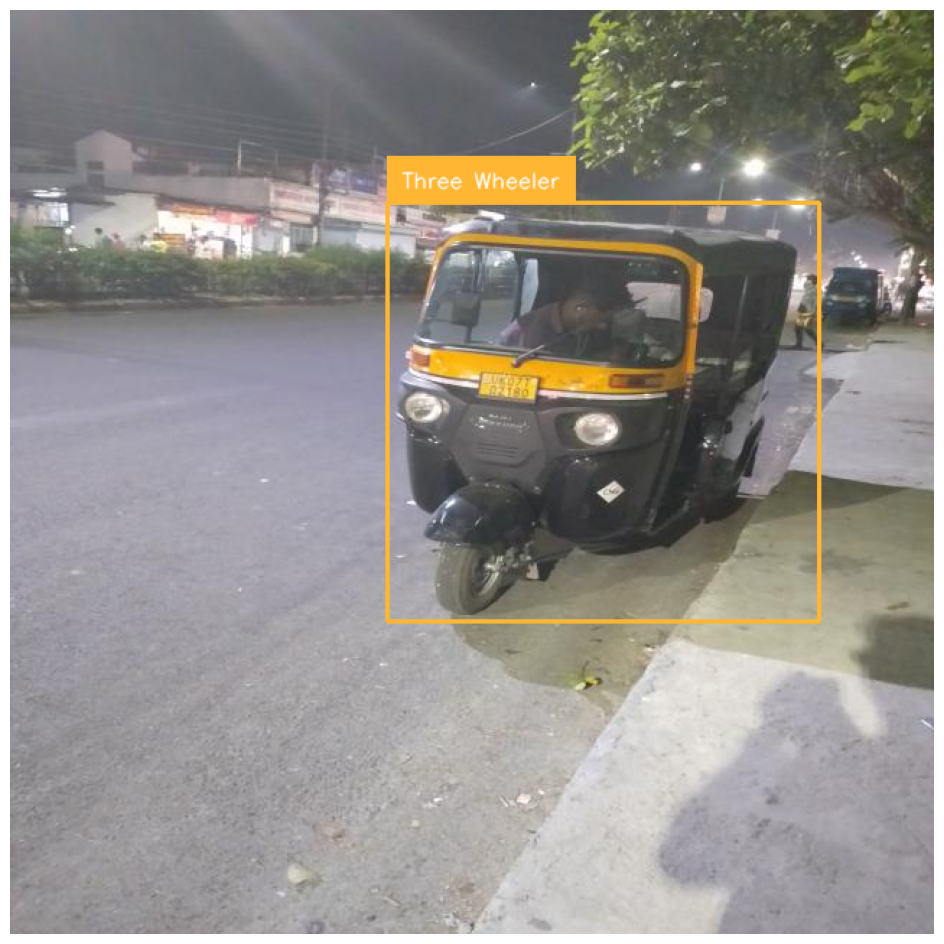

In [ ]:
import glob, cv2, supervision as sv

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

test_images = glob.glob(f"{dataset.location}/test/images/*.jpg")
image = cv2.imread(test_images[0])
result = final_model(image)[0]
detections = sv.Detections.from_ultralytics(result)

annotated = box_annotator.annotate(scene=image.copy(), detections=detections)
annotated = label_annotator.annotate(scene=annotated, detections=detections)
sv.plot_image(annotated)

## 6. Standout feature: PCU Traffic Congestion Analyzer

**Passenger Car Unit (PCU)** normalizes different vehicle types into one comparable "road space" unit. A bus doesn't just count as "one vehicle," it counts as roughly 3 cars' worth of road occupancy. This is standard practice in Indian transportation engineering (IRC SP-41 / IRC:106-1990 guidelines).

**Weights used below**, with sourcing:
- Car = 1.0, Two Wheeler = 0.5, Bus/Truck = 3.0 while these are the commonly-cited IRC SP-41 standard values.
- Three Wheeler ≈ 0.75, Vikram (tempo/LCV) ≈ 1.5, Tractor ≈ 4.0, approximate values drawn from PCU literature on Indian mixed-traffic conditions; these vary by study, road geometry, and traffic composition (real published estimates for two-wheelers alone range from 0.13 to 0.5 depending on methodology), so treat these as a transparent, reproducible baseline rather than a precise calibrated constant.
- Modified = 1.0 — treated as a car-equivalent, since it's an ambiguous class (customized vehicles of varying size) with no standard PCU value to draw on.
- Fixed Obstacle = 0.0 — excluded from the PCU sum entirely, since it isn't a vehicle and has no road-occupancy analog.

**Honest limitation:** This is a heuristic occupancy proxy from single-frame detections, not a calibrated traffic-flow measurement (no speed, headway, or lane data), a natural next step would be to calibrate these weights empirically against this dataset itself.

In [ ]:
# Upload a short traffic video via the Colab file browser (left sidebar) first,
# or run: from google.colab import files; uploaded = files.upload()

VIDEO_PATH = "/content/indian_traffic_congestion.mp4"
OUTPUT_VIDEO_PATH = "traffic_clip_pcu_annotated.mp4"

PCU_WEIGHTS = {
    "Car": 1.0,
    "Two Wheeler": 0.5,
    "Three Wheeler": 0.75,
    "Vikram": 1.5,
    "Bus": 3.0,
    "Truck": 3.0,
    "Tractor": 4.0,
    "Modified": 1.0,       # treated as car-equivalent — ambiguous class
    "Fixed Obstacle": 0.0, # not a vehicle; excluded from PCU sum
}

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import copy
cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS) or 24
w, h = int(cap.get(3)), int(cap.get(4))
out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

frame_pcu_scores = []
peak_frame = None
peak_score = -1
frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    result = final_model(frame, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(result)
    class_names = [data_cfg["names"][c] for c in detections.class_id]

    pcu_score = sum(PCU_WEIGHTS.get(name, 1.0) for name in class_names)
    frame_pcu_scores.append(pcu_score)

    if pcu_score > peak_score:
        peak_score = pcu_score
        peak_frame = (frame.copy(), copy.deepcopy(detections))

    annotated = box_annotator.annotate(scene=frame.copy(), detections=detections)
    annotated = label_annotator.annotate(scene=annotated, detections=detections)
    cv2.putText(annotated, f"PCU: {pcu_score:.1f}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)
    out.write(annotated)
    frame_idx += 1

cap.release()
out.release()
print(f"Processed {frame_idx} frames. Saved annotated video to {OUTPUT_VIDEO_PATH}")

Processed 2412 frames. Saved annotated video to traffic_clip_pcu_annotated.mp4


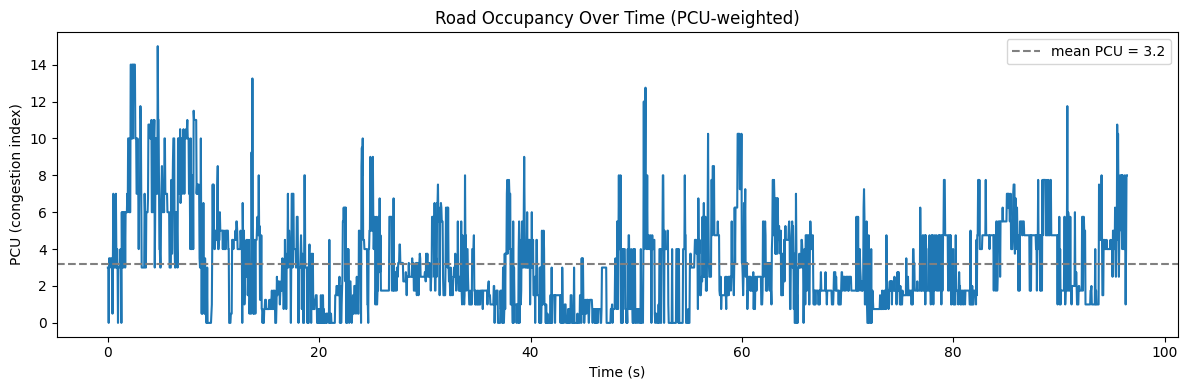

Peak congestion: PCU = 15.0


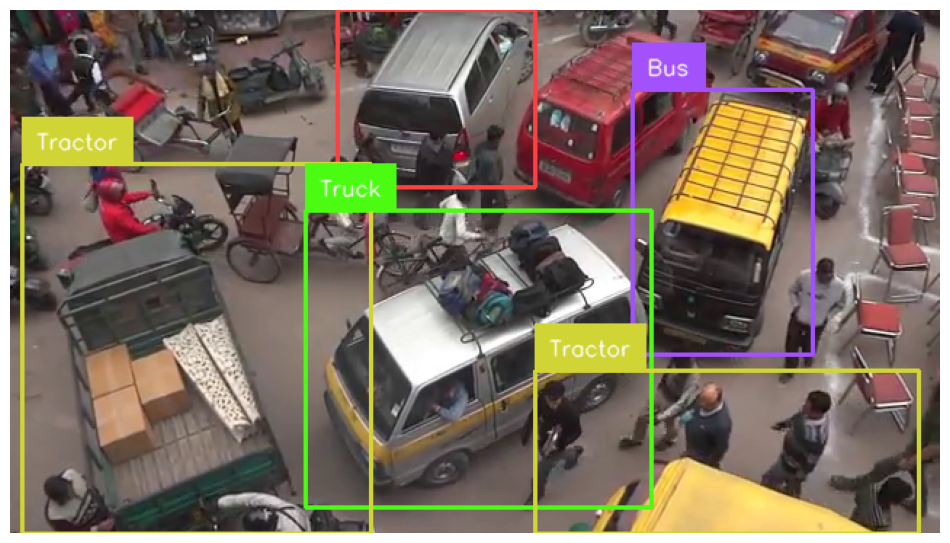

In [ ]:
# Congestion timeline
timestamps = np.arange(len(frame_pcu_scores)) / fps

plt.figure(figsize=(12, 4))
plt.plot(timestamps, frame_pcu_scores, linewidth=1.5)
plt.axhline(np.mean(frame_pcu_scores), color="gray", linestyle="--", label=f"mean PCU = {np.mean(frame_pcu_scores):.1f}")
plt.xlabel("Time (s)")
plt.ylabel("PCU (congestion index)")
plt.title("Road Occupancy Over Time (PCU-weighted)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{DRIVE_ROOT}/pcu_timeline.png", dpi=150)
plt.show()

# Peak congestion frame
peak_img, peak_dets = peak_frame
peak_annotated = box_annotator.annotate(scene=peak_img.copy(), detections=peak_dets)
peak_annotated = label_annotator.annotate(scene=peak_annotated, detections=peak_dets)
print(f"Peak congestion: PCU = {peak_score:.1f}")
sv.plot_image(peak_annotated)

## 7. Export & README summary

In [18]:
FINAL_EPOCHS = 50
BASE_MODEL = "yolo26s.pt"
summary = f"""
## Indian Traffic Object Detection — YOLO26 + PCU Congestion Analyzer

Fine-tuned YOLO26 on the Indian Traffic Objects dataset (Roboflow Universe, 2.8k images, 9 classes:
{', '.join(data_cfg['names'])}).

### Hyperparameter selection
Compared three configs (baseline / conservative fine-tune with a frozen backbone / aggressive
augmentation) over {COMPARE_EPOCHS} epochs each before committing to a full run. Results were close
(within ~0.02 mAP50-95 of each other), so the winner was chosen by margin, not a dramatic gap:

{compare_df.to_string(index=False)}

Winning config: **{WINNING_CONFIG}**, trained for {FINAL_EPOCHS} epochs on {BASE_MODEL}.

### Results
- mAP50: {metrics.box.map50:.3f}
- mAP50-95: {metrics.box.map:.3f}
- Known limitation: class imbalance. Fixed Obstacle is the most represented class (~2,600 instances)
  yet still underperforms on mAP50-95, most likely due to label ambiguity rather than data volume.
  Two Wheeler is the single weakest class, likely due to small object size and occlusion in dense
  traffic — see per-class breakdown above for the full picture.

### Standout feature: PCU Congestion Analyzer
Converts detections into an IRC-standard Passenger Car Unit (PCU) score per frame
(bus/truck = 3.0, car = 1.0, two-wheeler = 0.5, etc.) and plots road occupancy over
a video timeline, rather than just drawing boxes. Peak-congestion frame identified
automatically. Limitation: single-frame heuristic, not a calibrated flow measurement.
"""
print(summary)


## Indian Traffic Object Detection — YOLO26 + PCU Congestion Analyzer

Fine-tuned YOLO26 on the Indian Traffic Objects dataset (Roboflow Universe, 2.8k images, 9 classes:
Bus, Car, Fixed Obstacle, Modified, Three Wheeler, Tractor, Truck, Two Wheeler, Vikram).

### Hyperparameter selection
Compared three configs (baseline / conservative fine-tune with a frozen backbone / aggressive
augmentation) over 12 epochs each before committing to a full run. Results were close
(within ~0.02 mAP50-95 of each other), so the winner was chosen by margin, not a dramatic gap:

        config  mAP50  mAP50-95
      baseline 0.8511    0.6545
  conservative 0.8471    0.6542
aggressive_aug 0.8650    0.6339

Winning config: **baseline**, trained for 50 epochs on yolo26s.pt.

### Results
- mAP50: 0.890
- mAP50-95: 0.693
- Known limitation: class imbalance. Fixed Obstacle is the most represented class (~2,600 instances)
  yet still underperforms on mAP50-95, most likely due to label ambiguity rather than data

In [ ]:
from google.colab import files
files.download(OUTPUT_VIDEO_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

(recovery cell for resuming in a fresh runtime)

In [6]:
from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO
import yaml

DRIVE_ROOT = "/content/drive/MyDrive/indian-traffic-yolo26"
BEST_WEIGHTS = f"{DRIVE_ROOT}/final_run/weights/best.pt"

# point at wherever your dataset's data.yaml is (redownload from Roboflow if needed, it's fast)
data_yaml_path = "/content/Indian-traffic-objects-1/data.yaml"

with open(data_yaml_path) as f:
    data_cfg = yaml.safe_load(f)

model = YOLO(BEST_WEIGHTS)
metrics = model.val(data=data_yaml_path)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("\nPer-class mAP50-95:")
for cls_name, ap in zip(data_cfg["names"], metrics.box.maps):
    print(f"  {cls_name}: {round(ap, 3)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.122 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,468,663 parameters, 0 gradients, 20.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1400.4±277.8 MB/s, size: 60.4 KB)
val: Scanning /content/Indian-traffic-objects-1/valid/labels... 552 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 552/552 1.7Kit/s 0.3s
val: New cache created: /content/Indian-traffic-objects-1/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):

## 8. Additional Analysis Visualizations
Built from metrics object from the trained model.

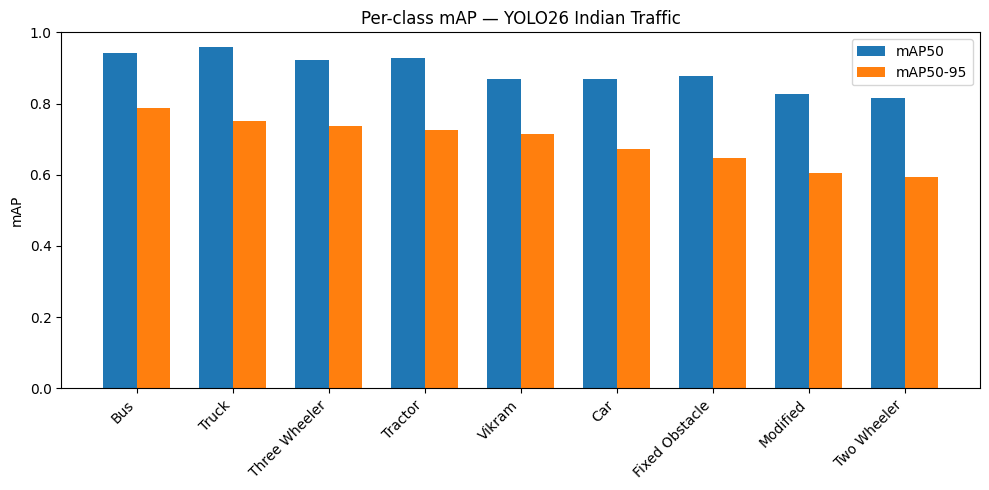

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# metrics.box.ap50  -> per-class mAP50
# metrics.box.maps  -> per-class mAP50-95
class_names = data_cfg["names"]
map50 = metrics.box.ap50
map5095 = metrics.box.maps

data = dict(zip(class_names, zip(map50, map5095)))
data = dict(sorted(data.items(), key=lambda x: x[1][1], reverse=True))

classes = list(data.keys())
map50_vals = [v[0] for v in data.values()]
map5095_vals = [v[1] for v in data.values()]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, map50_vals, width, label="mAP50")
ax.bar(x + width/2, map5095_vals, width, label="mAP50-95")

ax.set_ylabel("mAP")
ax.set_title("Per-class mAP — YOLO26 Indian Traffic")
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()

plt.savefig(f"{DRIVE_ROOT}/per_class_map.png", dpi=150)
plt.show()

In [11]:
import os
compare_dir = f"{DRIVE_ROOT}/hparam_compare"
for name in ["baseline", "conservative", "aggressive_aug"]:
    path = f"{compare_dir}/{name}/results.csv"
    print(name, "->", os.path.exists(path))

baseline -> True
conservative -> True
aggressive_aug -> True


In [12]:
import pandas as pd

compare_results = []
for name in ["baseline", "conservative", "aggressive_aug"]:
    df = pd.read_csv(f"{compare_dir}/{name}/results.csv")
    df.columns = df.columns.str.strip()
    last_row = df.iloc[-1]
    compare_results.append({
        "config": name,
        "mAP50": round(last_row["metrics/mAP50(B)"], 4),
        "mAP50-95": round(last_row["metrics/mAP50-95(B)"], 4),
    })

compare_df = pd.DataFrame(compare_results).sort_values("mAP50-95", ascending=False)
print(compare_df)

WINNING_CONFIG = compare_df.iloc[0]["config"]
print(f"\nWinning config: {WINNING_CONFIG}")

           config   mAP50  mAP50-95
0        baseline  0.8511    0.6545
1    conservative  0.8471    0.6542
2  aggressive_aug  0.8650    0.6339

Winning config: baseline


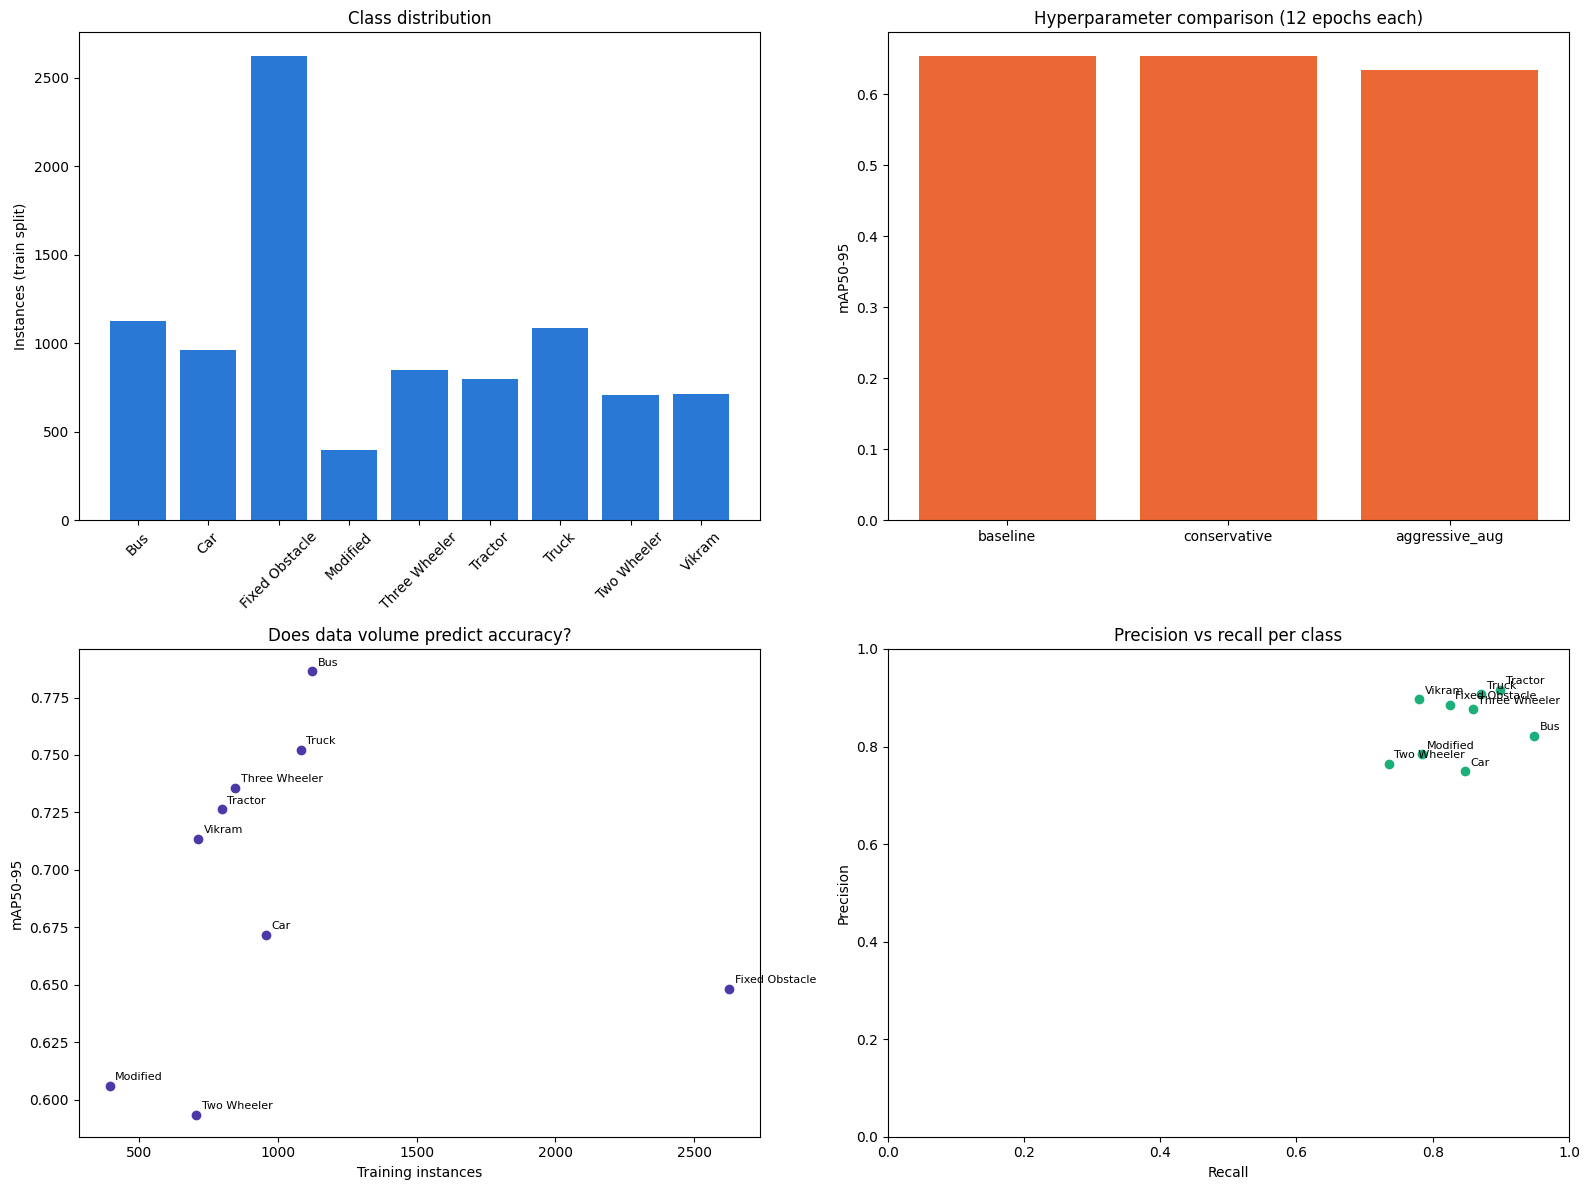

In [16]:
COMPARE_EPOCHS = 12
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Class distribution
train_counts = count_classes("train")
counts = [train_counts[c] for c in data_cfg["names"]]
axes[0, 0].bar(data_cfg["names"], counts, color="#2a78d6")
axes[0, 0].set_ylabel("Instances (train split)")
axes[0, 0].set_title("Class distribution")
axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Hyperparameter comparison
axes[0, 1].bar(compare_df["config"], compare_df["mAP50-95"], color="#eb6834")
axes[0, 1].set_ylabel("mAP50-95")
axes[0, 1].set_title(f"Hyperparameter comparison ({COMPARE_EPOCHS} epochs each)")

# 3. Instance count vs accuracy
ap = metrics.box.maps
axes[1, 0].scatter(counts, ap, color="#4a3aa7")
for i, name in enumerate(data_cfg["names"]):
    axes[1, 0].annotate(name, (counts[i], ap[i]), fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[1, 0].set_xlabel("Training instances")
axes[1, 0].set_ylabel("mAP50-95")
axes[1, 0].set_title("Does data volume predict accuracy?")

# 4. Precision vs Recall per class
precision = metrics.box.p
recall = metrics.box.r
axes[1, 1].scatter(recall, precision, color="#1baf7a")
for i, name in enumerate(data_cfg["names"]):
    axes[1, 1].annotate(name, (recall[i], precision[i]), fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[1, 1].set_xlabel("Recall")
axes[1, 1].set_ylabel("Precision")
axes[1, 1].set_xlim(0, 1); axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title("Precision vs recall per class")

plt.tight_layout()
plt.savefig(f"{DRIVE_ROOT}/analysis_grid.png", dpi=150)
plt.show()